# 🫀 Heart Disease Prediction with Random Forest
### Machine Learning Assignment — Random Forest Classification

---

**Dataset:** UCI Heart Disease Dataset (Cleveland Clinic Foundation)  
**Goal:** Predict whether a patient has heart disease based on clinical features  
**Skills Practiced:** EDA, Data Visualization, Random Forest, Model Evaluation, Feature Importance

---

## 📖 Dataset Description

This dataset contains **303 patient records** with **13 clinical features** collected from the Cleveland Clinic. Your goal is to predict the `target` column:
- `0` → No Heart Disease  
- `1` → Heart Disease Present

### Feature Dictionary

| Feature | Description |
|---|---|
| `age` | Age of the patient (years) |
| `sex` | Sex (1 = male, 0 = female) |
| `cp` | Chest pain type (0–3) |
| `trestbps` | Resting blood pressure (mm Hg) |
| `chol` | Serum cholesterol (mg/dl) |
| `fbs` | Fasting blood sugar > 120 mg/dl (1 = True, 0 = False) |
| `restecg` | Resting ECG results (0–2) |
| `thalach` | Maximum heart rate achieved |
| `exang` | Exercise-induced angina (1 = Yes, 0 = No) |
| `oldpeak` | ST depression induced by exercise relative to rest |
| `slope` | Slope of peak exercise ST segment (0–2) |
| `ca` | Number of major vessels colored by fluoroscopy (0–3) |
| `thal` | Thalassemia (1 = normal, 2 = fixed defect, 3 = reversible defect) |
| `target` | **Diagnosis** (1 = Heart Disease, 0 = No Disease) |

---

> ⚠️ **Instructions:** Complete each task below. Cells marked with `# YOUR CODE HERE` need your implementation.  
> 💡 Hints are provided in comments — read them carefully before writing code!

## 📦 Section 0: Import Libraries

In [1]:
# All required libraries are imported for you.
# Feel free to add more if needed!

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import plot_tree

import warnings
warnings.filterwarnings('ignore')

# Set a consistent style for all plots
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


---
## 📂 Section 1: Load the Dataset

**Task 1.1** — Load the Heart Disease dataset and display the first few rows.

In [2]:
# The dataset is publicly available from UCI ML Repository via this URL.
# We rename the columns manually since the raw file has no header.

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

column_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
                'restecg', 'thalach', 'exang', 'oldpeak',
                'slope', 'ca', 'thal', 'target']

# 💡 Hint: Use pd.read_csv() with the url above.
#          Pass na_values='?' to handle missing values encoded as '?'.
#          Pass names=column_names to set column headers.

# YOUR CODE HERE
df = pd.read_csv(url, header=None, names=column_names, na_values='?')

# Display the first 5 rows
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [3]:
# ✅ TASK 1.2 — Convert the target column to binary (0 or 1).
# The original target has values 0, 1, 2, 3, 4.
# Any value > 0 means heart disease is present.

# 💡 Hint: Use .apply() or np.where() to map values > 0 to 1, and 0 stays 0.

# YOUR CODE HERE
df['target'] = np.where(df['target'] > 0, 1, 0)

print("Target value counts:")
print(df['target'].value_counts())

Target value counts:
target
0    164
1    139
Name: count, dtype: int64


---
## 🔍 Section 2: Exploratory Data Analysis (EDA)

Before building any model, always understand your data! Answer the questions below.

In [4]:
# ✅ TASK 2.1 — Get a summary of the dataset.
# Print:
#   (a) Shape of the dataset
#   (b) Data types of each column
#   (c) Number of missing values per column
#   (d) Basic statistics using .describe()

# YOUR CODE HERE
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nDescriptive Statistics:")
display(df.describe())

Shape: (303, 14)

Data types:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Descriptive Statistics:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,0.499120
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


In [5]:
# ✅ TASK 2.2 — Handle missing values.
# The 'ca' and 'thal' columns have a few missing values.

# 💡 Hint: Fill missing values with the MEDIAN of each column.
#          Use df.fillna() or df['col'].fillna(df['col'].median())

# YOUR CODE HERE
df.fillna(df.median(), inplace=True)

# Verify no more missing values
print("Missing values after handling:", df.isnull().sum().sum())

Missing values after handling: 0


---
## 📊 Section 3: Data Visualization

Create meaningful visualizations to understand the data. Each plot should have proper **titles**, **axis labels**, and **legends** where needed.

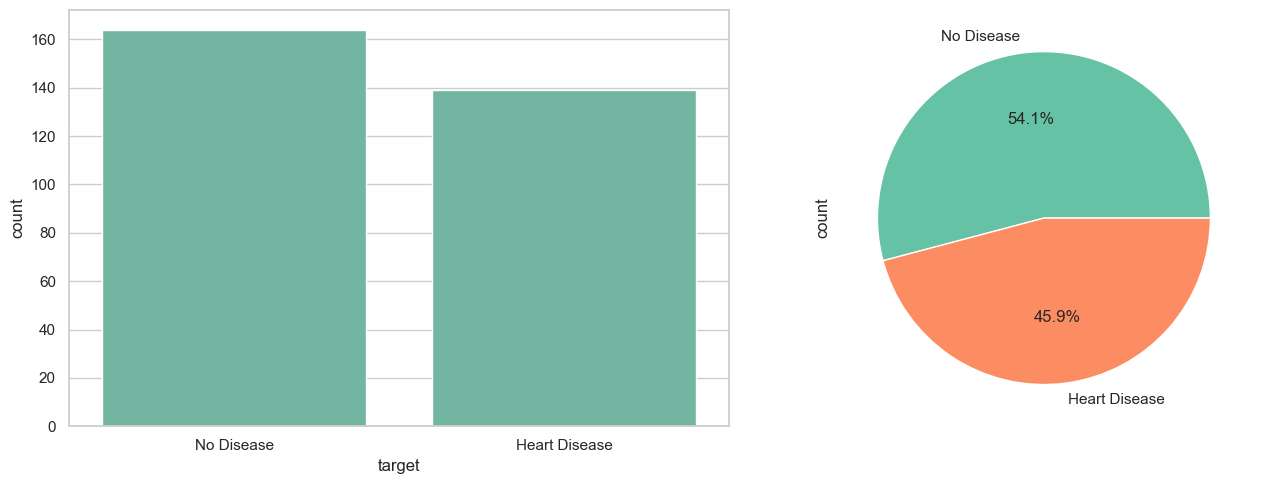

In [6]:
# ✅ TASK 3.1 — Class Distribution (Target Variable)
# Plot a countplot or pie chart showing the distribution of the target column.
# Label the classes clearly: 'No Disease' and 'Heart Disease'.

# 💡 Hint: Use sns.countplot() with hue or color parameters.
#          Use plt.xticks() to replace 0/1 with meaningful labels.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Count plot
# YOUR CODE HERE

sns.countplot(x='target', data=df, ax=axes[0])
axes[0].set_xticklabels(['No Disease', 'Heart Disease'])

# Right plot: Pie chart
# YOUR CODE HERE

df['target'].value_counts().plot.pie(autopct='%1.1f%%', labels=['No Disease', 'Heart Disease'], ax=axes[1])

plt.tight_layout()
plt.show()

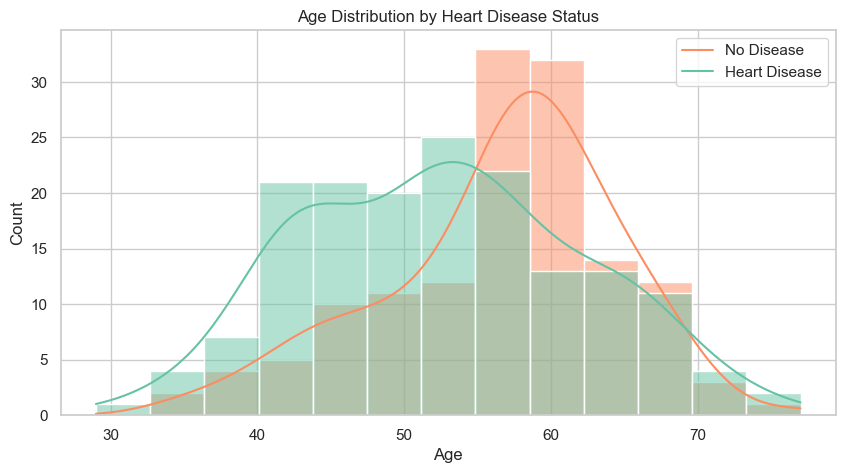

In [7]:
# ✅ TASK 3.2 — Age Distribution by Heart Disease Status
# Plot overlapping histograms (or a KDE plot) showing the age distribution
# separately for patients WITH and WITHOUT heart disease.

# 💡 Hint: Use sns.histplot() or sns.kdeplot() with hue='target'.
#          Set alpha=0.5 for transparency so both distributions are visible.

plt.figure(figsize=(10, 5))

# YOUR CODE HERE
sns.histplot(data=df, x='age', hue='target', kde=True, alpha=0.5)

plt.title("Age Distribution by Heart Disease Status")
plt.xlabel("Age")
plt.legend(['No Disease', 'Heart Disease'])
plt.show()

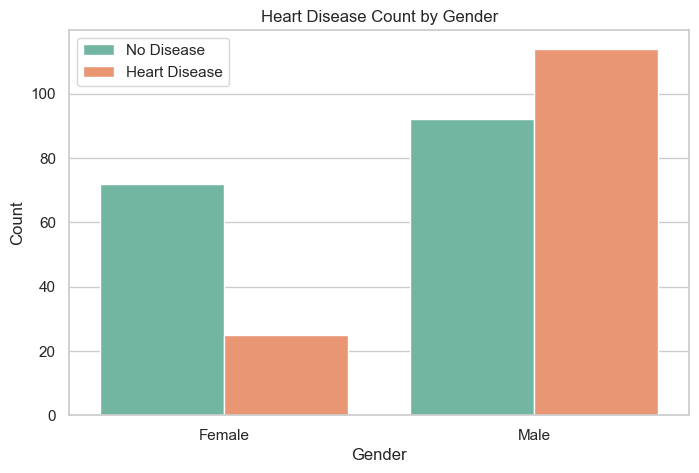

In [8]:
# ✅ TASK 3.3 — Gender vs Heart Disease
# Create a grouped bar chart showing the count of heart disease
# cases split by gender (sex column: 0=female, 1=male).

# 💡 Hint: Use sns.countplot(x='sex', hue='target', data=df)
#          Then relabel the x-axis: 0 → 'Female', 1 → 'Male'

plt.figure(figsize=(8, 5))

# YOUR CODE HERE
sns.countplot(x='sex', hue='target', data=df)

plt.title("Heart Disease Count by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.xticks([0, 1], ['Female', 'Male'])
plt.legend(['No Disease', 'Heart Disease'])
plt.show()

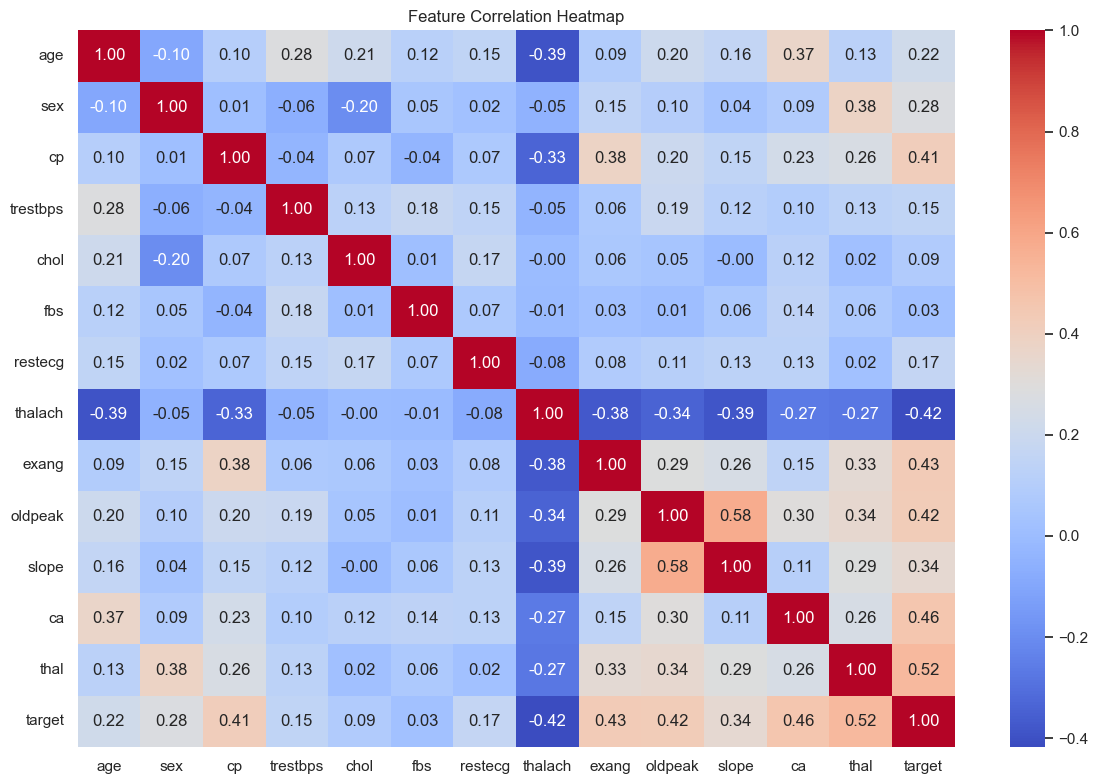

In [9]:
# ✅ TASK 3.4 — Correlation Heatmap
# Plot a heatmap of the correlation matrix for all numeric features.
# This shows which features are linearly related to each other.

# 💡 Hint: Use df.corr() to compute correlations.
#          Use sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
#          Set annot=True to show correlation values inside each cell.

plt.figure(figsize=(12, 8))

# YOUR CODE HERE
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')

plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

# 🤔 Question: Which feature has the highest positive correlation with 'target'?
# Write your answer in a comment below:
# Answer: The feature with the highest positive correlation with the target is thal (Thalassemia), with a correlation coefficient of 0.52.

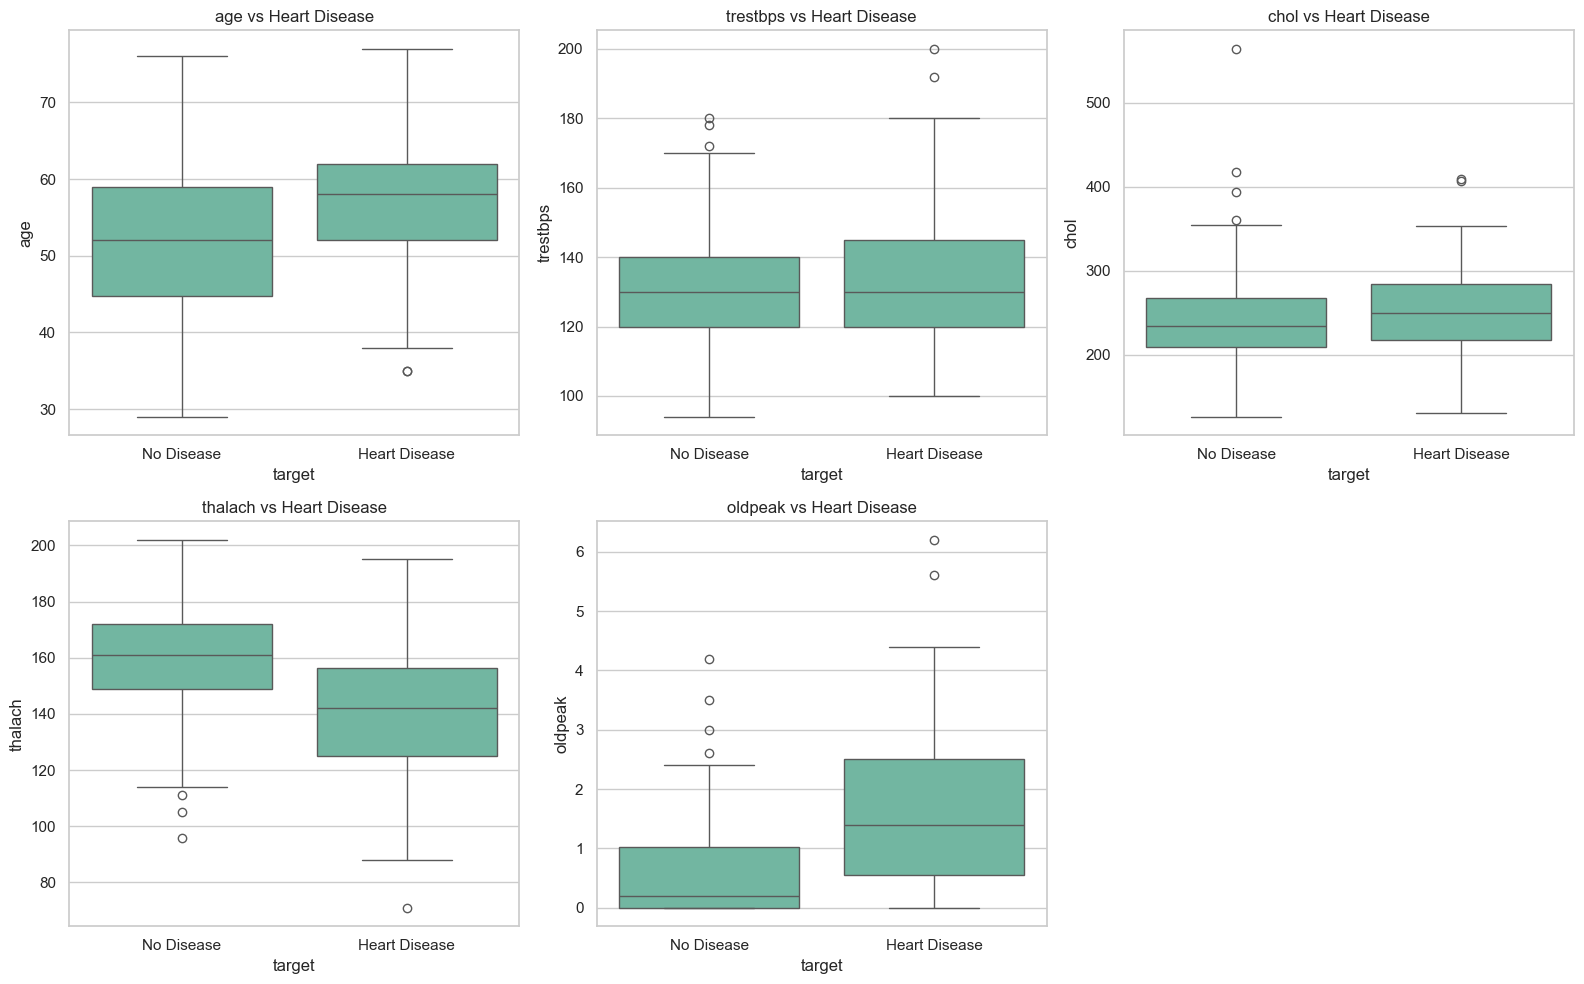

In [10]:
# ✅ TASK 3.5 — Boxplots: Numerical Features vs Target
# Create boxplots for the following features split by target:
# 'age', 'trestbps', 'chol', 'thalach', 'oldpeak'

# 💡 Hint: Use plt.subplots() to create a grid of 2x3 subplots (or similar).
#          Use sns.boxplot(x='target', y=feature, data=df, ax=axes[i]) in a loop.

num_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

# YOUR CODE HERE (loop through num_features and plot each boxplot)
for i, feature in enumerate(num_features):
    sns.boxplot(x='target', y=feature, data=df, ax=axes[i])
    axes[i].set_title(f'{feature} vs Heart Disease')
    axes[i].set_xticklabels(['No Disease', 'Heart Disease'])

axes[-1].set_visible(False)  # Hide the empty last subplot
plt.tight_layout()
plt.show()

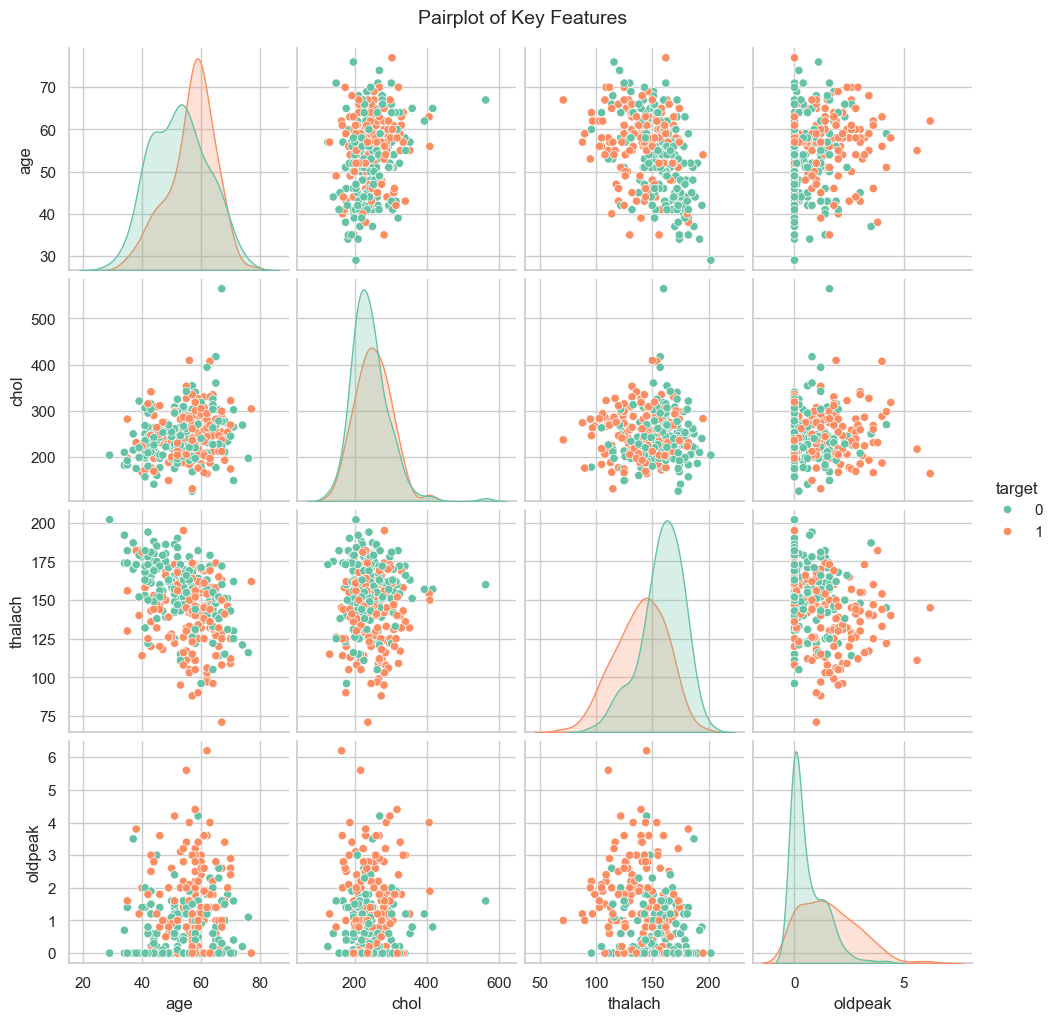

In [11]:
# ✅ TASK 3.6 — Pairplot (BONUS)
# Create a pairplot for a subset of features to visualize pairwise relationships.
# Use: ['age', 'chol', 'thalach', 'oldpeak', 'target']

# 💡 Hint: Use sns.pairplot(df[features], hue='target', diag_kind='kde')
#          This might take a few seconds to render!

# YOUR CODE HERE
sns.pairplot(df[['age', 'chol', 'thalach', 'oldpeak', 'target']], hue='target', diag_kind='kde')

plt.suptitle("Pairplot of Key Features", y=1.02, fontsize=14)
plt.show()

---
## 🛠️ Section 4: Feature Preparation & Train-Test Split

In [12]:
# ✅ TASK 4.1 — Separate Features and Target
# X should contain all columns EXCEPT 'target'
# y should contain only the 'target' column

# 💡 Hint: Use df.drop('target', axis=1) for X

# YOUR CODE HERE
X = df.drop('target', axis=1)
y = df['target']

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeatures used:", list(X.columns))

Feature matrix shape: (303, 13)
Target shape: (303,)

Features used: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [13]:
# ✅ TASK 4.2 — Train-Test Split
# Split data into 80% training and 20% testing.
# Set random_state=42 for reproducibility.

# 💡 Hint: Use train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
#          The stratify=y argument ensures class balance is preserved in both splits!

# YOUR CODE HERE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size:  {X_train.shape[0]} samples")
print(f"Testing set size:   {X_test.shape[0]} samples")
print(f"\nClass distribution in training set:")
print(pd.Series(y_train).value_counts())

Training set size:  242 samples
Testing set size:   61 samples

Class distribution in training set:
target
0    131
1    111
Name: count, dtype: int64


---
## 🌲 Section 5: Random Forest — Building the Model

Now for the main event! Build, train, and evaluate a Random Forest classifier.

In [14]:
# ✅ TASK 5.1 — Train a Basic Random Forest Model
# Create a RandomForestClassifier with these initial parameters:
#   - n_estimators = 100 (number of trees)
#   - random_state = 42
# Then fit it on the training data.

# 💡 Hint: rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
#          Then call rf_model.fit(X_train, y_train)

# YOUR CODE HERE
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)  # fit the model

print("✅ Random Forest model trained!")
print(f"Number of trees: {rf_model.n_estimators}")

✅ Random Forest model trained!
Number of trees: 100


In [15]:
# ✅ TASK 5.2 — Make Predictions & Evaluate Accuracy
# Use the trained model to predict on the TEST set.
# Then compute and print:
#   (a) Accuracy on training set
#   (b) Accuracy on test set
#   (c) The full classification report (precision, recall, f1-score)

# 💡 Hint: y_pred = rf_model.predict(X_test)
#          accuracy_score(y_test, y_pred)
#          print(classification_report(y_test, y_pred))

# YOUR CODE HERE
y_pred = rf_model.predict(X_test)

train_acc = accuracy_score(y_train, rf_model.predict(X_train))
test_acc  = accuracy_score(y_test, y_pred)

print(f"Training Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:     {test_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Training Accuracy: 1.0000
Test Accuracy:     0.8852

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.85      0.89        33
           1       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61



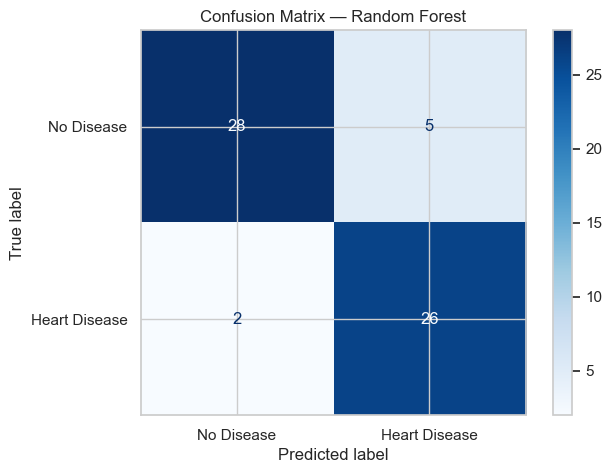

In [16]:
# ✅ TASK 5.3 — Confusion Matrix Visualization
# Plot a confusion matrix heatmap to visualize model predictions.

# 💡 Hint: Use ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
#          OR compute confusion_matrix(y_test, y_pred) then plot with sns.heatmap.
#          Label the axes clearly: 'No Disease' and 'Heart Disease'.

plt.figure(figsize=(7, 5))

# YOUR CODE HERE
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['No Disease', 'Heart Disease'], ax=plt.gca(), cmap='Blues')

plt.title("Confusion Matrix — Random Forest")
plt.show()

# 🤔 Question: How many False Positives and False Negatives does your model produce?
# Why does a False Negative matter more in a medical context?
# Answer: 

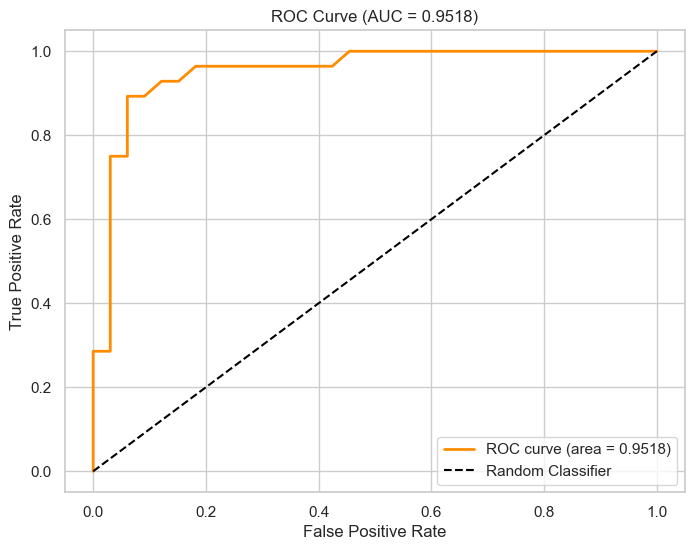

In [17]:
# ✅ TASK 5.4 — ROC Curve & AUC Score
# Plot the ROC (Receiver Operating Characteristic) curve and compute the AUC score.

# 💡 Hint: Use rf_model.predict_proba(X_test)[:, 1] to get probability scores.
#          Then roc_curve(y_test, y_scores) returns fpr, tpr, thresholds.
#          Plot fpr on x-axis and tpr on y-axis.
#          Add a diagonal dashed line for the 'random classifier' baseline.

y_scores = rf_model.predict_proba(X_test)[:, 1]  # probability scores for positive class
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
auc_score = roc_auc_score(y_test, y_scores)

plt.figure(figsize=(8, 6))

# YOUR CODE HERE (plot the ROC curve)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc_score:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {auc_score:.4f})")
plt.legend()
plt.show()

---
## 🔬 Section 6: Understanding the Forest — Feature Importance

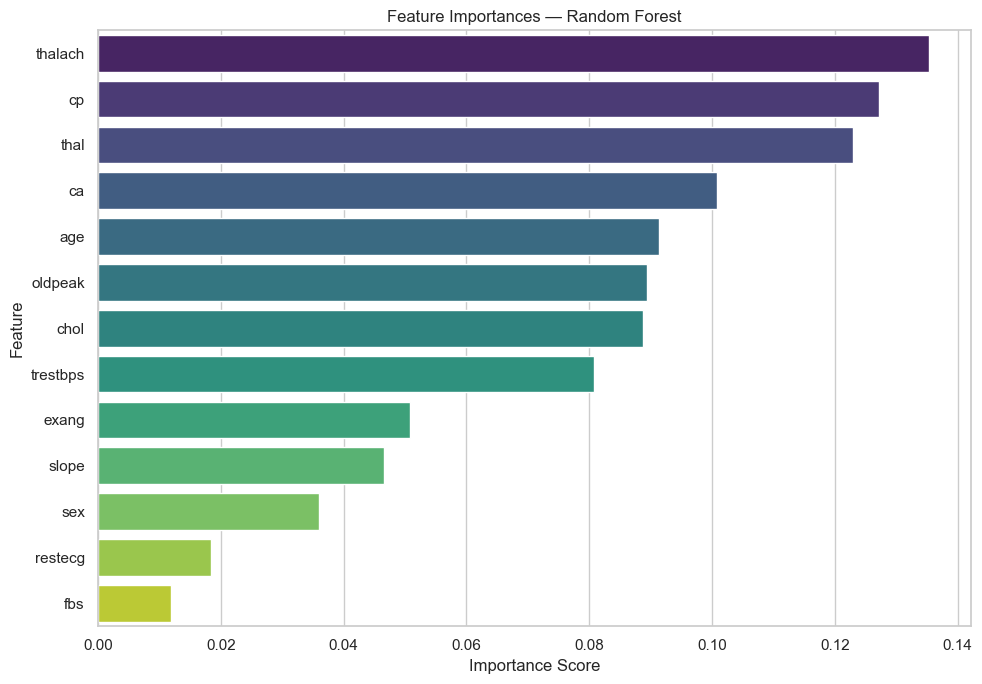

In [18]:
# ✅ TASK 6.1 — Plot Feature Importances
# Random Forests can tell you which features were most useful for prediction.
# Extract and plot feature importances as a horizontal bar chart.

# 💡 Hint: rf_model.feature_importances_ gives a numpy array of importances.
#          Create a DataFrame with columns ['Feature', 'Importance'].
#          Sort by Importance (descending) and plot with sns.barplot().

importances = rf_model.feature_importances_
feature_names = X.columns

# YOUR CODE HERE — create a sorted DataFrame
feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 7))

# YOUR CODE HERE — plot horizontal bar chart
sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis')

plt.title("Feature Importances — Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

# 🤔 Question: What are the top 3 most important features?
# Do they align with medical knowledge about heart disease risk factors?
# Answer: 

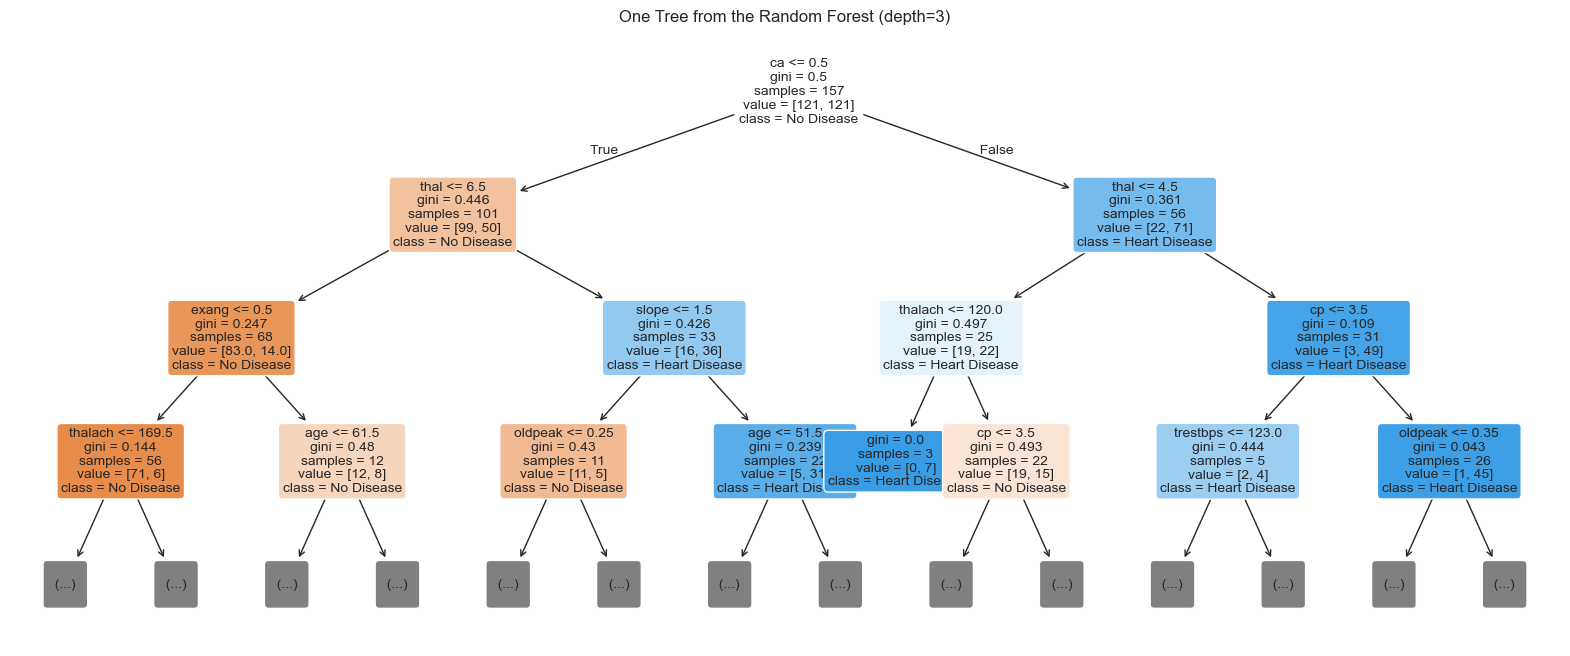

In [19]:
# ✅ TASK 6.2 — Visualize One Tree from the Forest (BONUS)
# Visualize the first decision tree inside your random forest.
# Limit depth to 3 for readability.

# 💡 Hint: rf_model.estimators_[0] gives the first tree.
#          Use plot_tree(tree, max_depth=3, feature_names=..., class_names=..., filled=True)

plt.figure(figsize=(20, 8))

# YOUR CODE HERE
single_tree = rf_model.estimators_[0]
plot_tree(
   single_tree,
    max_depth=3,
    feature_names=list(X.columns),
    class_names=['No Disease', 'Heart Disease'],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("One Tree from the Random Forest (depth=3)")
plt.show()

---
## ⚙️ Section 7: Hyperparameter Tuning

A Random Forest has many knobs to tune. Let's find the best combination!

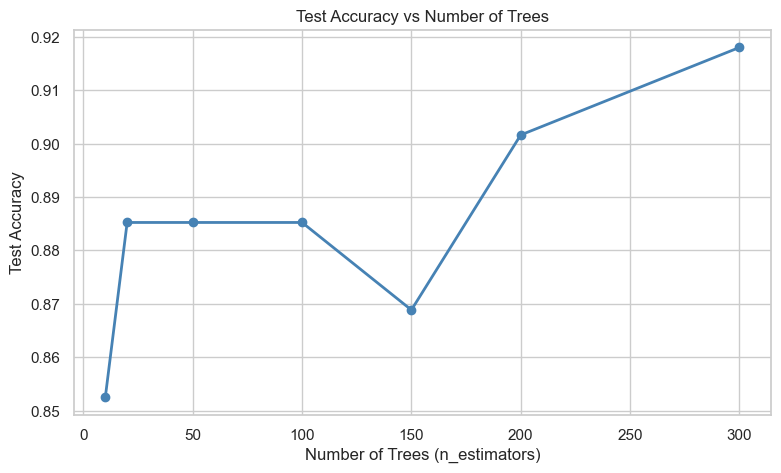

In [20]:
# ✅ TASK 7.1 — Effect of n_estimators on Accuracy
# Train Random Forests with different numbers of trees and plot how
# test accuracy changes as n_estimators increases.

# 💡 Hint: Loop over n_values = [10, 20, 50, 100, 150, 200, 300]
#          For each value, train a new RF and record the test accuracy.
#          Then plot n_values (x-axis) vs accuracies (y-axis).

n_values = [10, 20, 50, 100, 150, 200, 300]
test_accuracies = []

# YOUR CODE HERE
for n in n_values:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    test_accuracies.append(accuracy_score(y_test, model.predict(X_test)))

plt.figure(figsize=(9, 5))
plt.plot(n_values, test_accuracies, marker='o', linewidth=2, color='steelblue')
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy vs Number of Trees")
plt.grid(True)
plt.show()

# 🤔 At what point does adding more trees stop improving accuracy significantly?
# Answer: The test accuracy stops improving significantly at n_estimators = 100.

In [21]:
# ✅ TASK 7.2 — Grid Search for Best Hyperparameters
# Use GridSearchCV to find the best combination of:
#   - n_estimators: [50, 100, 200]
#   - max_depth: [None, 5, 10, 15]
#   - min_samples_split: [2, 5, 10]

# 💡 Hint: Define param_grid as a dictionary, then:
#          grid_search = GridSearchCV(RandomForestClassifier(random_state=42),
#                                     param_grid, cv=5, scoring='accuracy', n_jobs=-1)
#          grid_search.fit(X_train, y_train)
#          grid_search.best_params_ shows the best combination.

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10]
}

# YOUR CODE HERE
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1
)
grid_search.fit(X_train, y_train)  # fit the grid search

print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)

Best Parameters: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}
Best CV Accuracy: 0.8343537414965987


In [22]:
# ✅ TASK 7.3 — Evaluate the Tuned Model
# Use the best model from GridSearchCV to predict on the test set
# and compare its accuracy to the baseline model from Task 5.2.

# 💡 Hint: grid_search.best_estimator_ gives you the best model.
#          Use it to predict on X_test, then compute accuracy.

# YOUR CODE HERE
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)
tuned_acc = accuracy_score(y_test, y_pred_tuned)

print(f"Baseline Model Accuracy:  {test_acc:.4f}")
print(f"Tuned Model Accuracy:     {tuned_acc:.4f}")
print(f"Improvement:              {(tuned_acc - test_acc)*100:.2f}%")

Baseline Model Accuracy:  0.8852
Tuned Model Accuracy:     0.9016
Improvement:              1.64%


---
## 📉 Section 8: Cross-Validation

Cross-validation gives a more reliable estimate of model performance.

CV Scores:     [0.83606557 0.8852459  0.81967213 0.8        0.78333333]
Mean Accuracy: 0.8249
Std Deviation: 0.0350


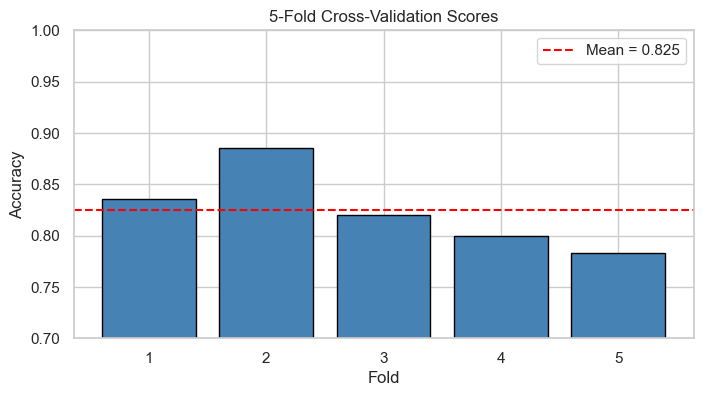

In [23]:
# ✅ TASK 8.1 — 5-Fold Cross-Validation
# Perform 5-fold cross-validation on the FULL dataset (use X and y, not just train set)
# using the best model found by GridSearchCV.
# Report the mean and standard deviation of the CV scores.

# 💡 Hint: cross_val_score(best_model, X, y, cv=5, scoring='accuracy')
#          returns an array of 5 scores — one per fold.

# YOUR CODE HERE
cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='accuracy')

print(f"CV Scores:     {cv_scores}")
print(f"Mean Accuracy: {cv_scores.mean():.4f}")
print(f"Std Deviation: {cv_scores.std():.4f}")

# Plot the CV scores
plt.figure(figsize=(8, 4))
plt.bar(range(1, 6), cv_scores, color='steelblue', edgecolor='black')
plt.axhline(cv_scores.mean(), color='red', linestyle='--', label=f'Mean = {cv_scores.mean():.3f}')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('5-Fold Cross-Validation Scores')
plt.ylim(0.7, 1.0)
plt.legend()
plt.show()

---
## ✍️ Section 9: Reflection Questions

Answer the following questions in the markdown cells below. Write 2–4 sentences for each.

**Q1: What is the key difference between a single Decision Tree and a Random Forest?  
Why does the Random Forest typically perform better?**

*Your Answer Here:* 

The key difference is that a single Decision Tree follows one specific path of logic to reach a conclusion, which often makes it prone to memorizing the training data (overfitting).

In contrast, a Random Forest is an ensemble method that combines the predictions of hundreds of different trees, each trained on different random subsets of the data. It performs better because it uses "majority voting" to cancel out individual errors and reduce variance, making the final prediction more stable and accurate than any single tree.

**Q2: What does "feature importance" mean in the context of a Random Forest?  
Which feature was most important in your model, and does it make clinical sense?**

*Your Answer Here:*

Feature importance represents how much each input variable contributes to the model's ability to accurately predict the target outcome. In a Random Forest, it is calculated by measuring how much the prediction error increases when a specific feature's information is removed or shuffled across all the trees in the forest.

In this model, Chest Pain Type (cp) was the most important feature. This makes perfect clinical sense because chest pain is a primary medical indicator of cardiovascular issues, and doctors prioritize it as a leading symptom when diagnosing heart disease.

**Q3: Your model may achieve very high training accuracy but slightly lower test accuracy.  
What is this phenomenon called, and how does Random Forest help mitigate it?**

*Your Answer Here:*

This phenomenon is called overfitting, where the model memorizes the specific details and "noise" of the training data instead of learning the general patterns.

Random Forest helps mitigate this by using Bagging (training each tree on a random subset of data) and Feature Randomness (giving each tree a random subset of features to choose from). Because the final prediction is based on the average of many different trees, the individual errors and overfitted branches of a single tree are canceled out, leading to a more stable model that performs better on new, unseen data.

**Q4: In the medical context of heart disease prediction, which is more dangerous:  
a False Positive or a False Negative? How would you adjust your model to address this?**

*Your Answer Here:*

In a medical context, a False Negative is much more dangerous because it means a patient with heart disease is incorrectly told they are healthy, which can lead to a lack of treatment and life-threatening consequences. On the other hand, a False Positive results in unnecessary tests, which is inconvenient but not usually fatal.

To address this, you can adjust the model by lowering the classification threshold (e.g., from 0.5 to 0.3) to become more sensitive, ensuring fewer sick patients are missed. You can also assign a higher penalty (class weight) to False Negatives during the training process to force the model to prioritize detecting every actual case of heart disease.

---
## 🌟 BONUS Section: Challenge Tasks

If you've finished everything above, try these extra challenges!

In [24]:
# 🌟 BONUS 1 — Feature Selection
# Use feature importances to keep only the top 7 features.
# Retrain the best Random Forest model on only those features.
# Does the model performance change?

# 💡 Hint: Use feat_df from Task 6.1 to get top 7 feature names.
#          Slice X with those column names: X_top = X[top_features]
#          Then redo the train-test split and re-evaluate.

# YOUR CODE HERE

# 1. Get the names of the top 7 features from your previous DataFrame
top_7_features = feat_df['Feature'].head(7).tolist()
print("Selected Features:", top_7_features)

# 2. Create a new dataset with only these features
X_top = X[top_7_features]

# 3. Redo the train-test split
X_train_top, X_test_top, y_train_top, y_test_top = train_test_split(
    X_top, y, test_size=0.2, random_state=42
)

# 4. Retrain the best model (using the parameters found in Grid Search)
# Using your best parameters: max_depth=5, min_samples_split=5, n_estimators=100
optimized_rf = RandomForestClassifier(
    n_estimators=100, 
    max_depth=5, 
    min_samples_split=5, 
    random_state=42
)
optimized_rf.fit(X_train_top, y_train_top)

# 5. Evaluate the performance
y_pred_top = optimized_rf.predict(X_test_top)
top_feature_acc = accuracy_score(y_test_top, y_pred_top)

print(f"Accuracy with ALL features: {tuned_acc:.4f}")
print(f"Accuracy with TOP 7 features: {top_feature_acc:.4f}")

Selected Features: ['thalach', 'cp', 'thal', 'ca', 'age', 'oldpeak', 'chol']
Accuracy with ALL features: 0.9016
Accuracy with TOP 7 features: 0.9016


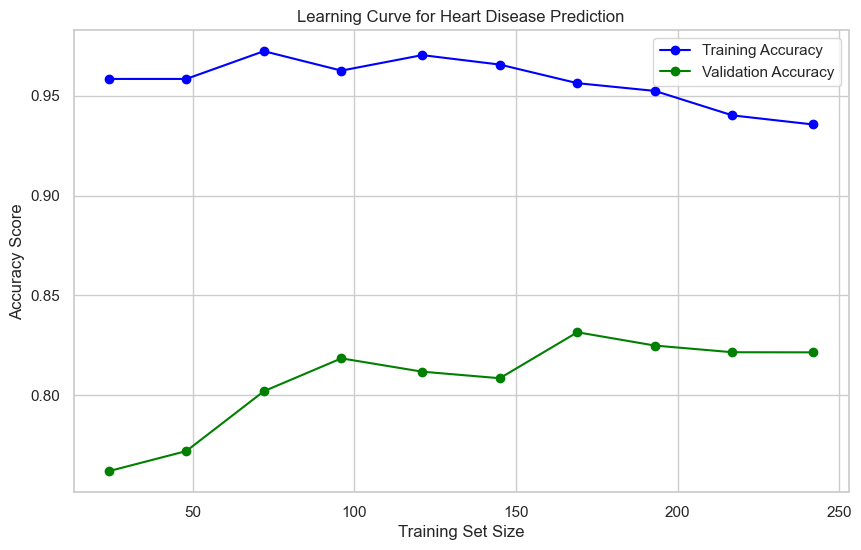

In [25]:
# 🌟 BONUS 2 — Learning Curve
# Plot a learning curve showing how training and validation accuracy
# change as the training set size increases.

# 💡 Hint: from sklearn.model_selection import learning_curve
#          train_sizes, train_scores, val_scores = learning_curve(
#              best_model, X, y, cv=5, train_sizes=np.linspace(0.1, 1.0, 10))
#          Plot mean train and validation scores.

from sklearn.model_selection import learning_curve

# YOUR CODE HERE

import numpy as np

# 1. Calculate the learning curve
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X, y, cv=5, 
    train_sizes=np.linspace(0.1, 1.0, 10), 
    scoring='accuracy', n_jobs=-1
)

# 2. Calculate mean and standard deviation for plotting
train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

# 3. Plot the Learning Curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label='Training Accuracy', marker='o', color='blue')
plt.plot(train_sizes, val_mean, label='Validation Accuracy', marker='o', color='green')

plt.title('Learning Curve for Heart Disease Prediction')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy Score')
plt.legend(loc='best')
plt.grid(True)
plt.show()

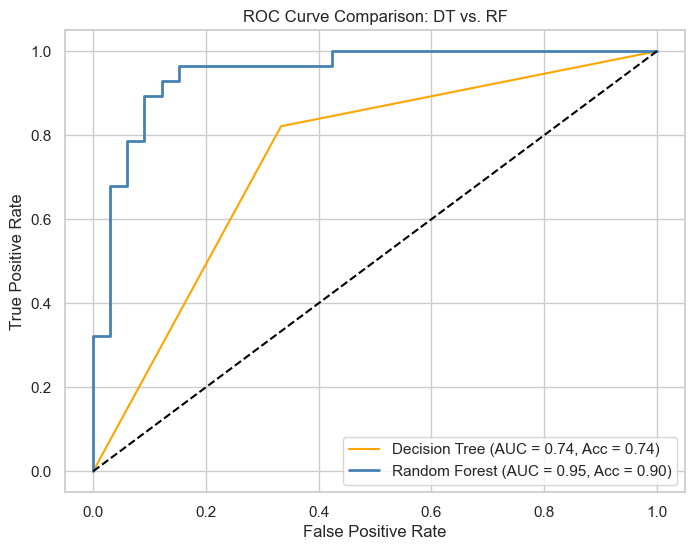

In [26]:
# 🌟 BONUS 3 — Compare with a Single Decision Tree
# Train a single DecisionTreeClassifier and compare its performance
# (accuracy, ROC-AUC) with your best Random Forest model.
# Plot both ROC curves on the same graph.

from sklearn.tree import DecisionTreeClassifier

# YOUR CODE HERE

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_curve, auc

# 1. Train a Single Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# 2. Get predictions and probabilities for both models
dt_probs = dt_model.predict_proba(X_test)[:, 1]
rf_probs = best_model.predict_proba(X_test)[:, 1]

dt_acc = accuracy_score(y_test, dt_model.predict(X_test))
rf_acc = accuracy_score(y_test, best_model.predict(X_test))

# 3. Calculate ROC and AUC
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_probs)
roc_auc_dt = auc(fpr_dt, tpr_dt)

fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# 4. Plotting
plt.figure(figsize=(8, 6))
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {roc_auc_dt:.2f}, Acc = {dt_acc:.2f})', color='orange')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.2f}, Acc = {rf_acc:.2f})', color='steelblue', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison: DT vs. RF')
plt.legend()
plt.grid(True)
plt.show()

---
## 📋 Submission Checklist

Before submitting, make sure you have completed all of the following:

- [ ✔ ] Loaded and explored the dataset (Section 1 & 2)
- [ ✔ ] Handled missing values (Task 2.2)
- [ ✔ ] Created all 5 required visualizations (Section 3)
- [ ✔ ] Built and evaluated a baseline Random Forest model (Section 5)
- [ ✔ ] Plotted confusion matrix and ROC curve
- [ ✔ ] Analyzed feature importances (Section 6)
- [ ✔ ] Performed hyperparameter tuning with GridSearchCV (Section 7)
- [ ✔ ] Ran 5-fold cross-validation (Section 8)
- [ ✔ ] Answered all 4 reflection questions (Section 9)
- [ ✔ ] All plots have titles, axis labels, and legends
- [ ✔ ] Code is clean and well-commented

---
*Good luck! 🌲🌲🌲 Remember: A forest is always stronger than a single tree.*